2025/10/08 10:51:59 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing KNN using PSO...


2025/10/08 10:52:15 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 7.03977 seconds
2025/10/08 10:52:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.68229 seconds
2025/10/08 10:52:38 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.45440 seconds
2025/10/08 10:52:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.36875 seconds
2025/10/08 10:53:01 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 11.36709 seconds
2025/10/08 10:53:01 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: Base

PSO Accuracy: 0.6228
PSO Best Params: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1}

Optimizing KNN using GA...


2025/10/08 10:53:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 11.58401 seconds
2025/10/08 10:53:36 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 11.62154 seconds
2025/10/08 10:53:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 11.64714 seconds
2025/10/08 10:53:53 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 5.73788 seconds
2025/10/08 10:54:02 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.583262511275617, Global best: -0.583262511275617, Runtime: 8.59911 seconds
2025/10/08 10:54:02 PM, INFO, mealpy.swarm_based.BA.OriginalBA: OriginalBA(ep

GA Accuracy: 0.5833
GA Best Params: {'n_neighbors': 3, 'weights': 'uniform', 'p': 1}

Optimizing KNN using Bat...


2025/10/08 10:54:16 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 1.68172 seconds
2025/10/08 10:54:19 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 2.71252 seconds
2025/10/08 10:54:21 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 2.64732 seconds
2025/10/08 10:54:24 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 2.66316 seconds
2025/10/08 10:54:25 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.6228458290777974, Global best: -0.6228458290777974, Runtime: 1.55543 seconds


Bat Accuracy: 0.6228
Bat Best Params: {'n_neighbors': 1, 'weights': 'uniform', 'p': 1}



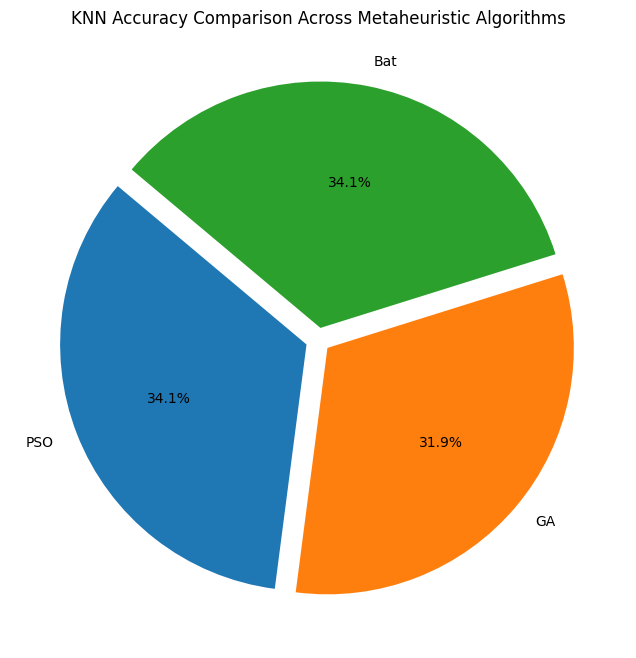

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# KNN Objective Function
# ----------------------------
def knn_objective_function(solution):
    n_neighbors = int(solution[0])
    weights_idx = int(solution[1])
    p = int(solution[2])
    weights = 'uniform' if weights_idx == 0 else 'distance'
    
    try:
        # Ensure n_neighbors is at least 1
        if n_neighbors < 1:
            n_neighbors = 1
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)
        scores = cross_val_score(knn, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)
    except:
        fitness = 1.0  # Return a high value for invalid parameters
    
    return fitness

# ----------------------------
# KNN Problem Definition
# ----------------------------
knn_problem = {
    "bounds": [
        FloatVar(lb=1, ub=20, name="n_neighbors"),
        FloatVar(lb=0, ub=1, name="weights"),  # 0 = 'uniform', 1 = 'distance'
        FloatVar(lb=1, ub=2, name="p")         # 1 = Manhattan, 2 = Euclidean
    ],
    "minmax": "min",
    "obj_func": knn_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing KNN using {name}...")
    best_agent = optimizer.solve(knn_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    weights = 'uniform' if int(best_solution[1]) == 0 else 'distance'
    p = int(best_solution[2])
    
    best_params = {
        'n_neighbors': int(best_solution[0]),
        'weights': weights,
        'p': p
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("KNN Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()


In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import warnings

# ----------------------------
# Mealpy algorithm imports (latest structure)
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACO  # Correct class name for ACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# KNN Objective Function
# ----------------------------
def knn_objective_function(solution):
    n_neighbors = max(1, int(solution[0]))
    weights_idx = int(solution[1])
    p = int(solution[2])
    weights = 'uniform' if weights_idx == 0 else 'distance'
    
    try:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)
        scores = cross_val_score(knn, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# KNN Problem Definition
# ----------------------------
knn_problem = {
    "bounds": [
        FloatVar(lb=1, ub=20, name="n_neighbors"),
        FloatVar(lb=0, ub=1, name="weights"),
        FloatVar(lb=1, ub=2, name="p")
    ],
    "minmax": "min",
    "obj_func": knn_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACO(epoch=5, pop_size=10),          # Corrected
    "Cuckoo": CSO.OriginalCS(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing KNN using {name}...")
    best_agent = optimizer.solve(knn_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    weights = 'uniform' if int(best_solution[1]) == 0 else 'distance'
    p = int(best_solution[2])
    best_params = {
        'n_neighbors': int(best_solution[0]),
        'weights': weights,
        'p': p
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Pie Chart
# ----------------------------
plt.figure(figsize=(10, 10))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("KNN Accuracy Comparison Across 7 Metaheuristic Algorithms")
plt.show()


ImportError: cannot import name 'OriginalACO' from 'mealpy.swarm_based.ACOR' (c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\mealpy\swarm_based\ACOR.py)